# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [3]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [4]:
%pip install --upgrade plotly

### Import Statements

In [5]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [6]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [7]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [8]:
df_data.shape

(4324, 9)

In [9]:
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [10]:
df_data.isna().sum().sort_values(ascending=False).head(10)

Price             3360
Unnamed: 0.1         0
Unnamed: 0           0
Location             0
Organisation         0
Date                 0
Detail               0
Rocket_Status        0
Mission_Status       0
dtype: int64

In [11]:
df_data.duplicated().sum()

np.int64(0)

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [12]:
df = df_data.copy()

In [13]:
junk_cols = [c for c in df.columns if 'Unnamed' in c]
df = df.drop(columns=junk_cols, errors='ignore')

In [14]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [23]:
df['Country'] = df['Location'].str.split(',').str[-1].str.strip()
df['Country']

0              USA
1            China
2              USA
3       Kazakhstan
4              USA
           ...    
4319           USA
4320           USA
4321           USA
4322    Kazakhstan
4323    Kazakhstan
Name: Country, Length: 4324, dtype: object

In [24]:
fix_map = {
    'Russia': 'Russian Federation',
    'USA': 'United States of America',
    'U.S.A.': 'United States of America',
    'United States': 'United States of America',
    'New Mexico': 'United States of America',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'United States of America',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'United States of America',
}

In [26]:
df['Country'] = df['Country'].replace(fix_map)
df['Country']

0       United States of America
1                          China
2       United States of America
3                     Kazakhstan
4       United States of America
                  ...           
4319    United States of America
4320    United States of America
4321    United States of America
4322                  Kazakhstan
4323                  Kazakhstan
Name: Country, Length: 4324, dtype: object

## Descriptive Statistics

In [30]:
org_counts = df['Organisation'].value_counts().head(15)

# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

<Axes: title={'center': 'Launches by Organisation'}, xlabel='Organisation'>

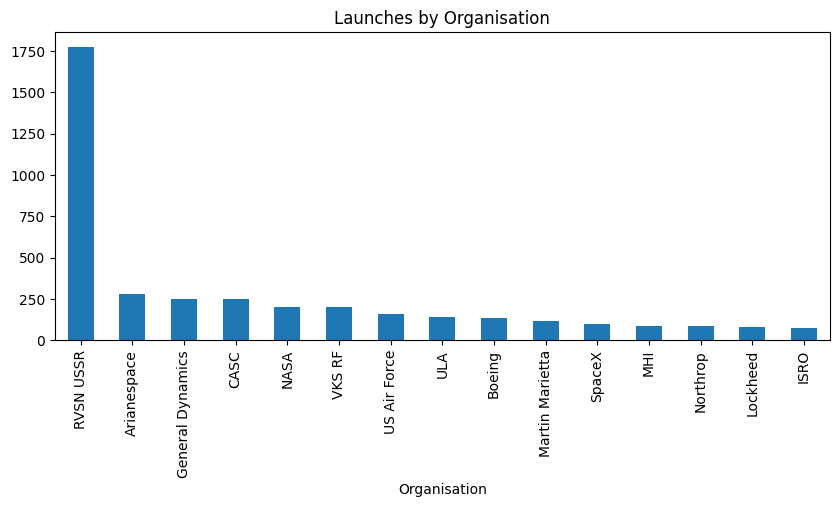

In [31]:
org_counts.plot(kind='bar', figsize=(10,4), title='Launches by Organisation')

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

<Axes: title={'center': 'Active vs Retired Rockets'}, xlabel='Rocket_Status'>

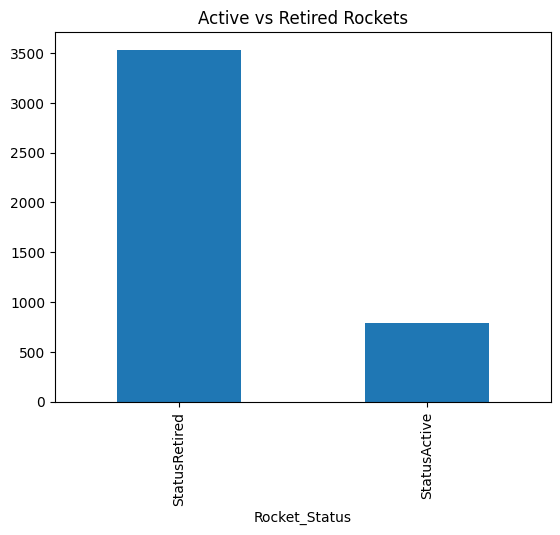

In [32]:
df['Rocket_Status'].value_counts().plot(kind='bar', title='Active vs Retired Rockets')

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

<Axes: title={'center': 'Mission Status %'}, xlabel='Mission_Status'>

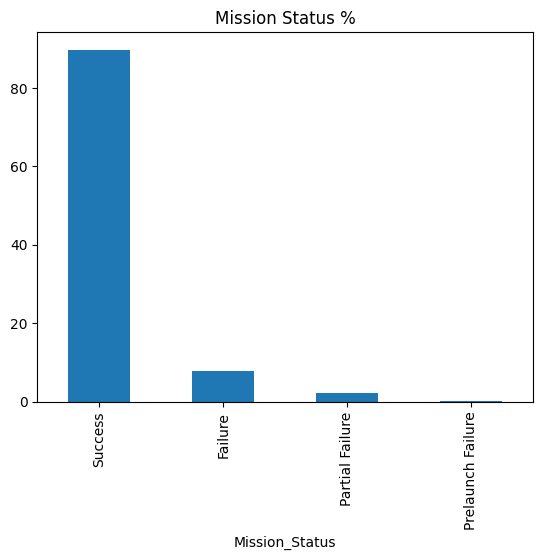

In [33]:
df['Mission_Status'].value_counts(normalize=True).mul(100).plot(kind='bar', title='Mission Status %')

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

Text(0.5, 1.0, 'Launch Price Distribution (USD millions)')

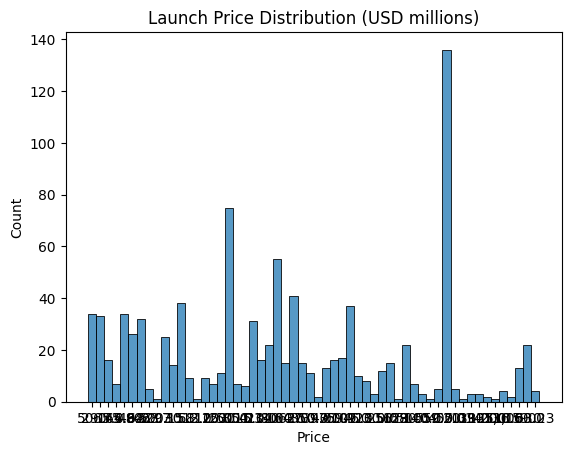

In [36]:
sns.histplot(df['Price'].dropna(), bins=40)
plt.title('Launch Price Distribution (USD millions)')

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [40]:
def to_alpha3(name):
    try:
        return countries.get(name).alpha3
    except:
        return None

df['alpha3'] = df['Country'].apply(to_alpha3)

In [41]:
df[['Location', 'Country', 'alpha3']].sample(10)

,Location,Country,alpha3
1157,"Site 32/1, Plesetsk Cosmodrome, Russia",Russian Federation,RUS
2506,"Site 132/1, Plesetsk Cosmodrome, Russia",Russian Federation,RUS
2696,"Site 32/2, Plesetsk Cosmodrome, Russia",Russian Federation,RUS
3840,"Uchinoura Space Center, Japan",Japan,JPN
2713,"Site 132/2, Plesetsk Cosmodrome, Russia",Russian Federation,RUS
1519,"SLC-36B, Cape Canaveral AFS, Florida, USA",United States of America,USA
1783,"Site 43/3, Plesetsk Cosmodrome, Russia",Russian Federation,RUS
1530,"SLC-3W, Vandenberg AFB, California, USA",United States of America,USA
206,"SLC-41, Cape Canaveral AFS, Florida, USA",United States of America,USA
790,"Site 16/2, Plesetsk Cosmodrome, Russia",Russian Federation,RUS


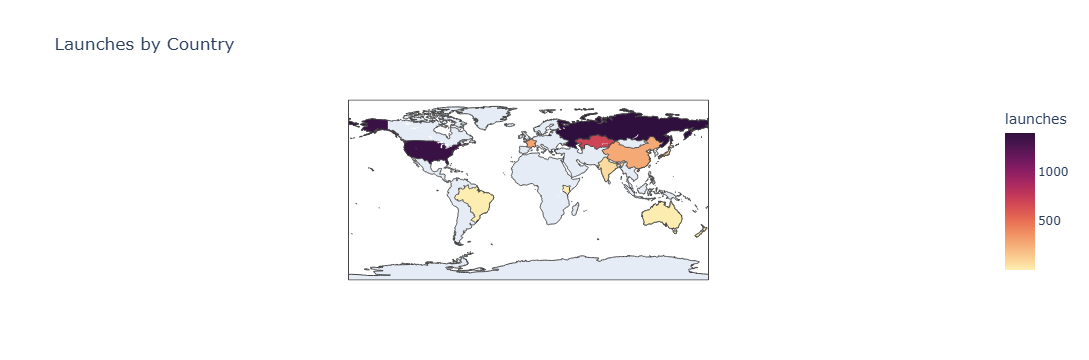

In [42]:
launches_by_country = df.groupby('alpha3').size().reset_index(name='launches')

px.choropleth(
    launches_by_country, locations='alpha3', color='launches',
    color_continuous_scale='matter', title='Launches by Country'
).show()

# Use a Choropleth Map to Show the Number of Failures by Country


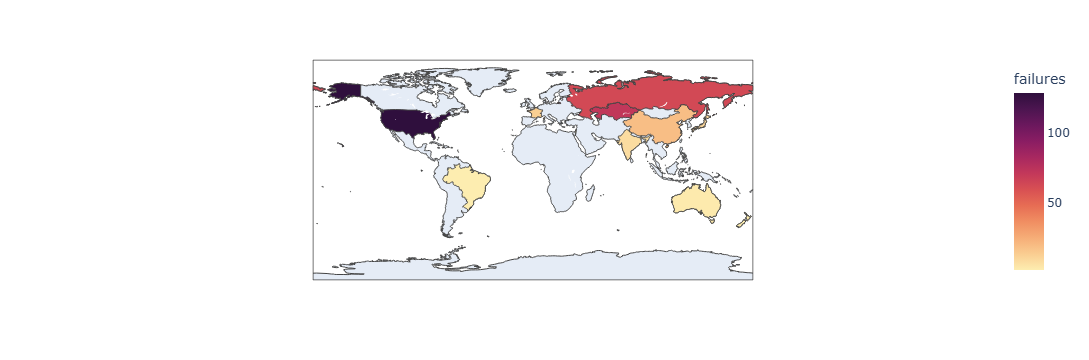

In [43]:
failures = df[df['Mission_Status'] == 'Failure'].groupby('alpha3').size().reset_index(name='failures')
px.choropleth(failures, locations='alpha3', color='failures', color_continuous_scale='matter').show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

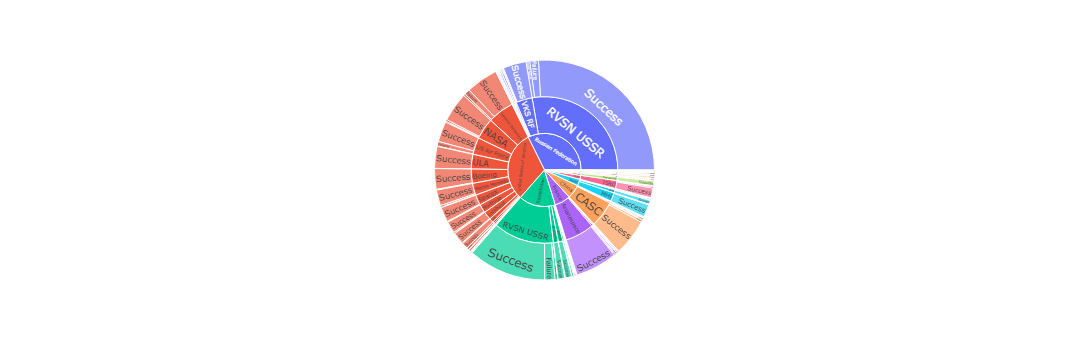

In [44]:
px.sunburst(df, path=['Country', 'Organisation', 'Mission_Status']).show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [46]:
df['Price'].sample(10)

2710      NaN
2803      NaN
971       NaN
3758     59.0
65       65.0
3944      NaN
525       NaN
1671    450.0
1170      NaN
3896      NaN
Name: Price, dtype: object

In [47]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)  # remove $, commas, text
)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [49]:
df['Price'].dtype

dtype('float64')

In [50]:
df['Price'].isna().sum()

np.int64(3360)

# Analyse the Amount of Money Spent by Organisation per Launch

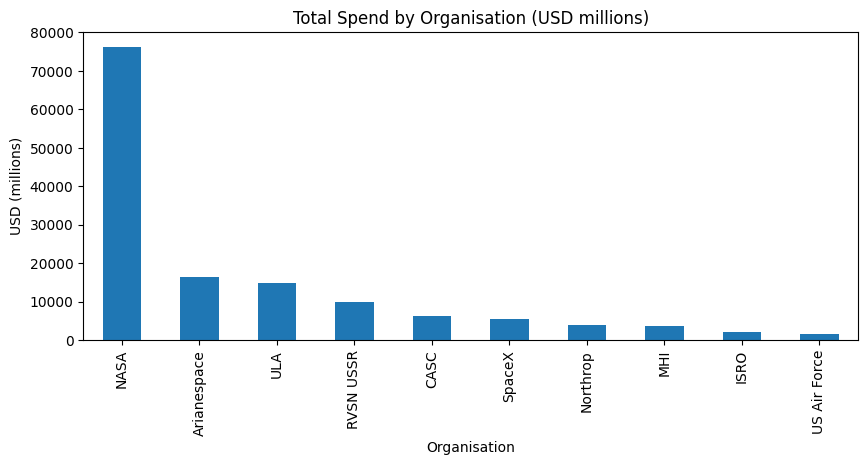

In [51]:
spent_by_org = (
    df.dropna(subset=['Price'])
      .groupby('Organisation')['Price']
      .sum()
      .sort_values(ascending=False)
)

spent_by_org.head(10).plot(kind='bar', figsize=(10,4), title='Total Spend by Organisation (USD millions)')
plt.ylabel("USD (millions)")
plt.show()

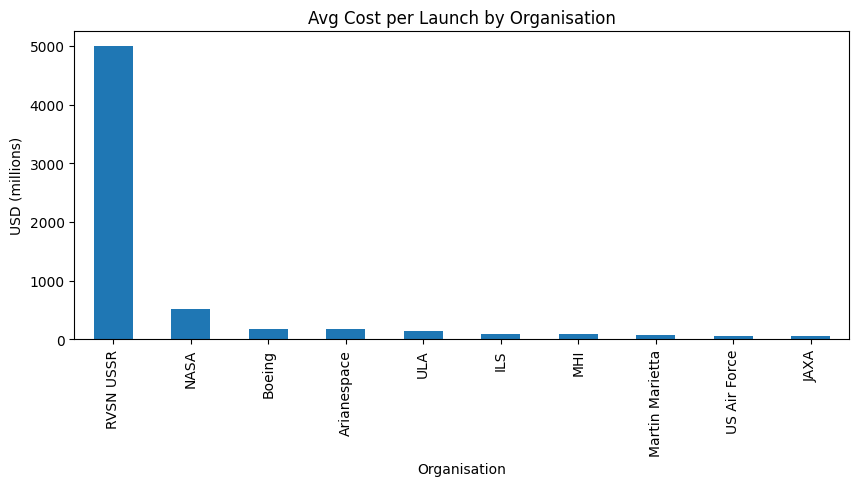

In [52]:
avg_price_by_org = (
    df.dropna(subset=['Price'])
      .groupby('Organisation')['Price']
      .mean()
      .sort_values(ascending=False)
)

avg_price_by_org.head(10).plot(kind='bar', figsize=(10,4), title='Avg Cost per Launch by Organisation')
plt.ylabel("USD (millions)")
plt.show()

# Chart the Number of Launches per Year

In [53]:
df['Year'] = df['Date'].dt.year
launches_per_year = df.groupby('Year').size()

<Axes: title={'center': 'Launches per Year'}, xlabel='Year'>

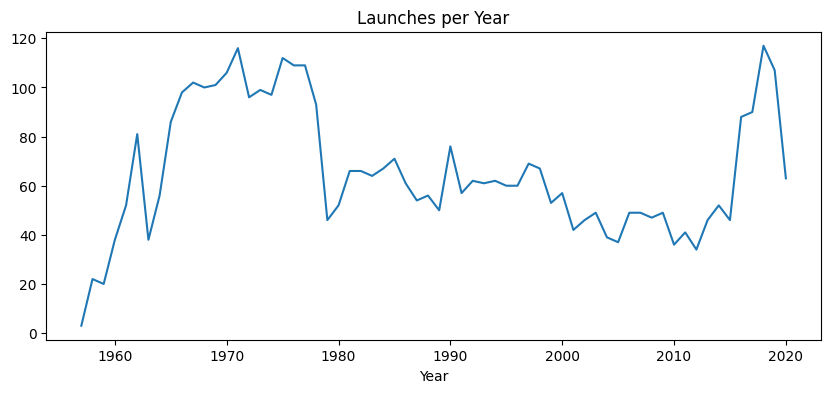

In [54]:
launches_per_year.plot(figsize=(10,4), title='Launches per Year')

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [58]:
monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str) + '-01'

0      1957.0-10.0-01
1      1957.0-11.0-01
2      1957.0-12.0-01
3       1958.0-2.0-01
4       1958.0-3.0-01
            ...      
742     2020.0-4.0-01
743     2020.0-5.0-01
744     2020.0-6.0-01
745     2020.0-7.0-01
746     2020.0-8.0-01
Length: 747, dtype: object

In [59]:
monthly['Year'] = monthly['Year'].astype(int)
monthly['Month'] = monthly['Month'].astype(int)

monthly['date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month'].astype(str).str.zfill(2) + '-01',
    format='%Y-%m-%d'
)

monthly = monthly.sort_values('date')
monthly['roll_6'] = monthly['count'].rolling(6).mean()


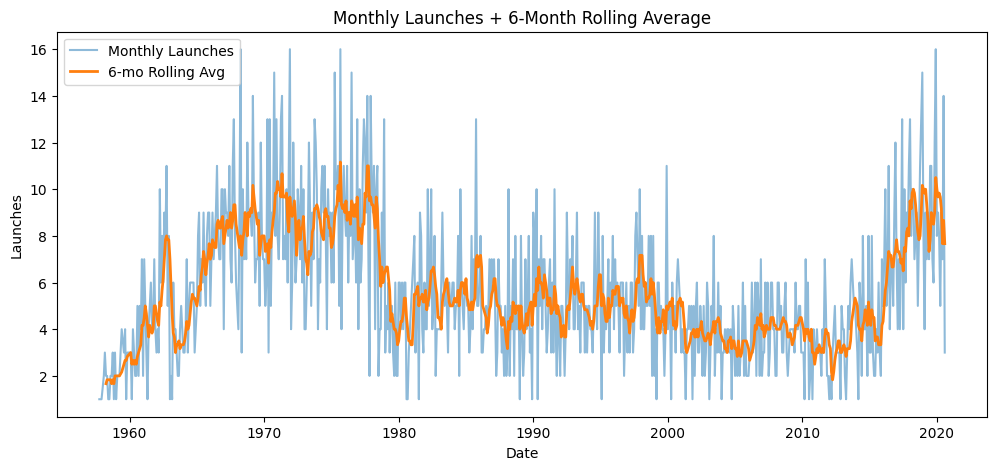

In [60]:
plt.figure(figsize=(12,5))
plt.plot(monthly['date'], monthly['count'], alpha=0.5, label='Monthly Launches')
plt.plot(monthly['date'], monthly['roll_6'], linewidth=2, label='6-mo Rolling Avg')
plt.legend()
plt.title('Monthly Launches + 6-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Launches')
plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [62]:
launches_by_month = (
    df.groupby(df['Date'].dt.month)
      .size()
      .rename_axis('Month')
      .reset_index(name='Launches')
      .sort_values('Launches', ascending=False)
)

launches_by_month

,Month,Launches
11,12.00,430
5,6.00,386
9,10.00,375
3,4.00,366
7,8.00,358
8,9.00,354
2,3.00,349
6,7.00,347
10,11.00,325
1,2.00,323


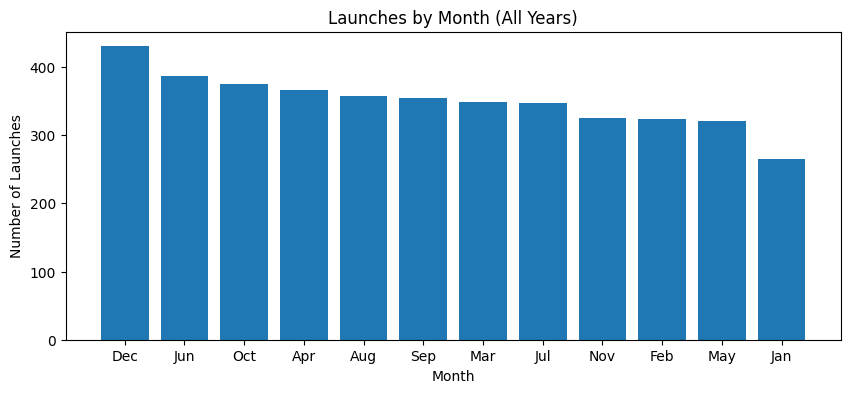

In [63]:
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

launches_by_month['MonthName'] = launches_by_month['Month'].map(month_names)

plt.figure(figsize=(10,4))
plt.bar(launches_by_month['MonthName'], launches_by_month['Launches'])
plt.title('Launches by Month (All Years)')
plt.xlabel('Month')
plt.ylabel('Number of Launches')
plt.show()

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

<Axes: title={'center': 'Average Launch Price Over Time'}, xlabel='Year'>

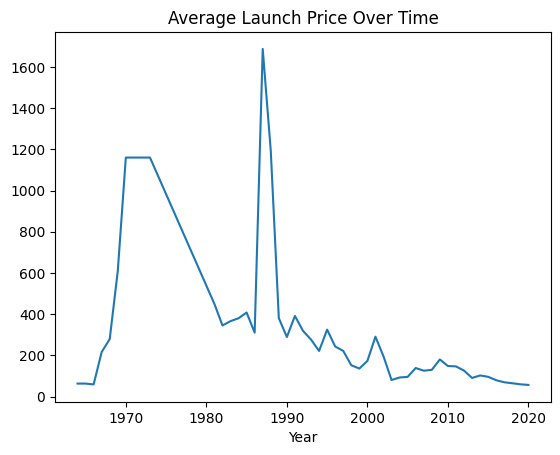

In [64]:
price_by_year = df.dropna(subset=['Price']).groupby('Year')['Price'].mean()
price_by_year.plot(title='Average Launch Price Over Time')

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [65]:
top10 = df['Organisation'].value_counts().head(10).index

In [66]:
pivot = df[df['Organisation'].isin(top10)].groupby(['Year','Organisation']).size().unstack(fill_value=0)

<Axes: xlabel='Year'>

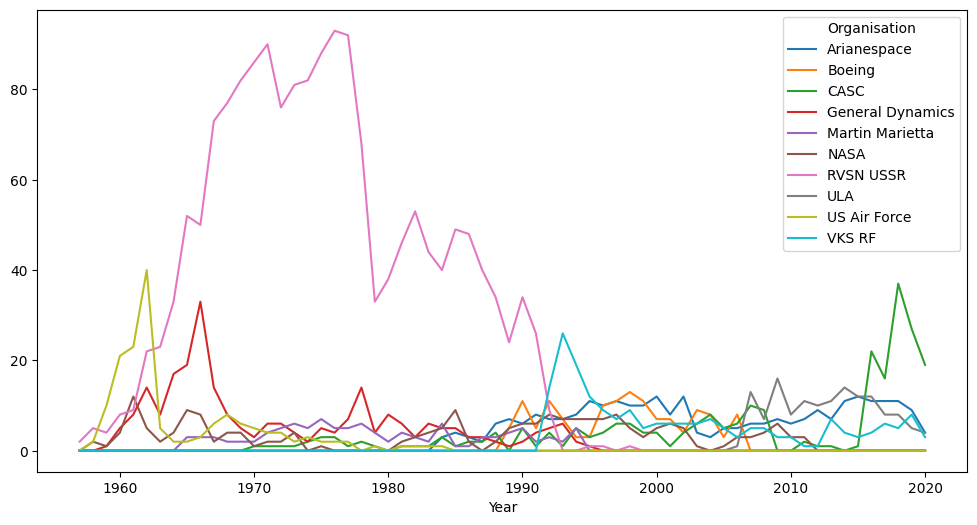

In [67]:
pivot.plot(figsize=(12,6))

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [80]:
USA = ['United States of America', 'USA']
USSR_BLOC = ['Russian Federation', 'Kazakhstan', 'Ukraine']

In [81]:
df_cold_war = df.copy()

usa_df = df_cold_war[df_cold_war['Country'].isin(USA)]
ussr_df = df_cold_war[df_cold_war['Country'].isin(USSR_BLOC)]

usa_total = usa_df.shape[0]
ussr_total = ussr_df.shape[0]

usa_total, ussr_total

(1351, 2099)

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [83]:
pie_df = pd.DataFrame({
    'Superpower': ['USA', 'USSR Bloc'],
    'Launches': [usa_total, ussr_total]
})

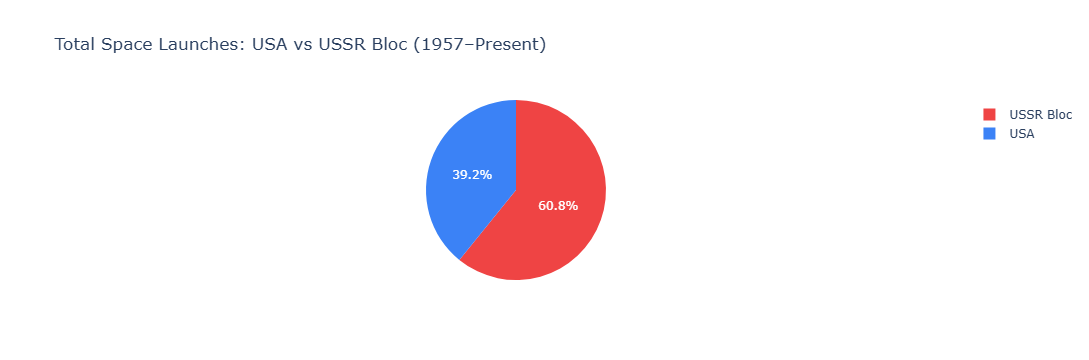

In [84]:
fig = px.pie(
    pie_df,
    names='Superpower',
    values='Launches',
    title='Total Space Launches: USA vs USSR Bloc (1957–Present)',
    color='Superpower',
    color_discrete_map={'USA': '#3b82f6', 'USSR Bloc': '#ef4444'}
)
fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [85]:
df['Year'] = df['Date'].dt.year

In [86]:
usa_yearly = (
    usa_df.groupby('Year')
    .size()
    .reset_index(name='USA')
)

ussr_yearly = (
    ussr_df.groupby('Year')
    .size()
    .reset_index(name='USSR_Bloc')
)

In [87]:
yearly = pd.merge(usa_yearly, ussr_yearly, on='Year', how='outer').fillna(0)
yearly = yearly.sort_values('Year')

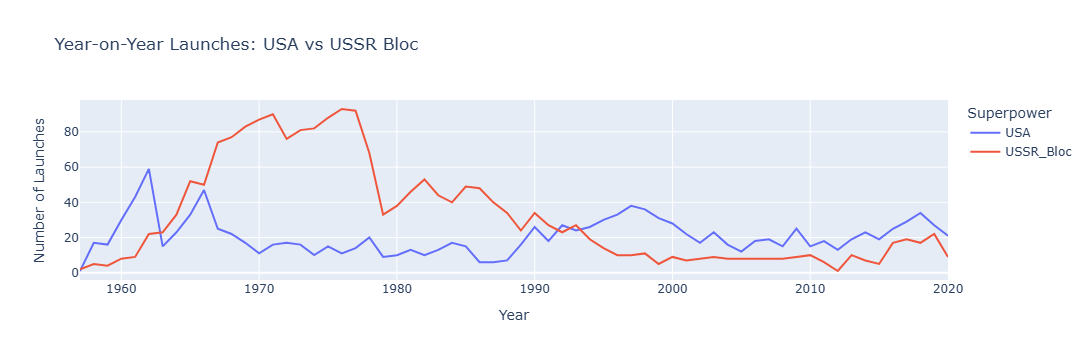

In [88]:
fig = px.line(
    yearly,
    x='Year',
    y=['USA', 'USSR_Bloc'],
    title='Year-on-Year Launches: USA vs USSR Bloc',
    labels={'value': 'Number of Launches', 'variable': 'Superpower'},
)
fig.show()

## Chart the Total Number of Mission Failures Year on Year.

In [89]:
df['Year'] = df['Date'].dt.year

In [91]:
failures_per_year = (
    df[df['Mission_Status'] == 'Failure']
    .groupby('Year')
    .size()
    .reset_index(name='Failures')
)

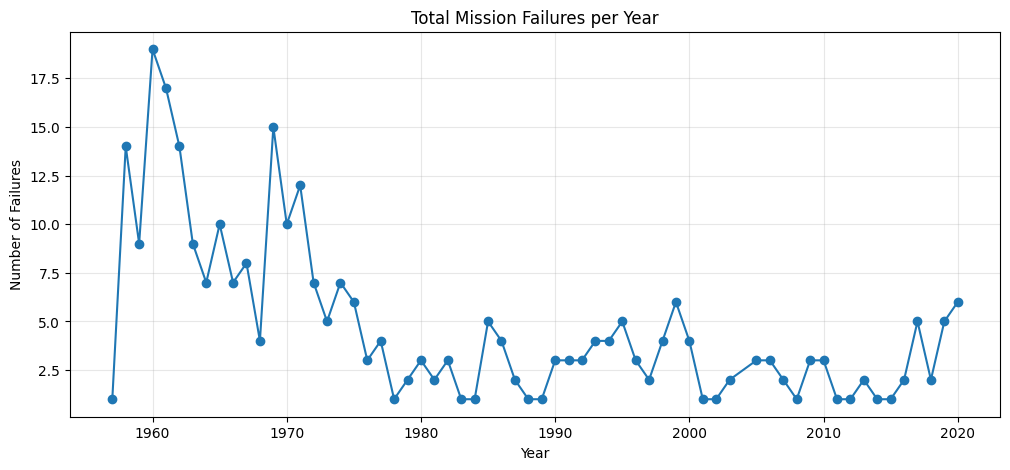

In [92]:
plt.figure(figsize=(12,5))
plt.plot(failures_per_year['Year'], failures_per_year['Failures'], marker='o')
plt.title('Total Mission Failures per Year')
plt.xlabel('Year')
plt.ylabel('Number of Failures')
plt.grid(alpha=0.3)
plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [93]:
total_per_year = (
    df.groupby('Year')
    .size()
    .reset_index(name='Total_Launches')
)

In [94]:
failure_rate = pd.merge(failures_per_year, total_per_year, on='Year', how='right').fillna(0)
failure_rate['Failure_%'] = (failure_rate['Failures'] / failure_rate['Total_Launches']) * 100

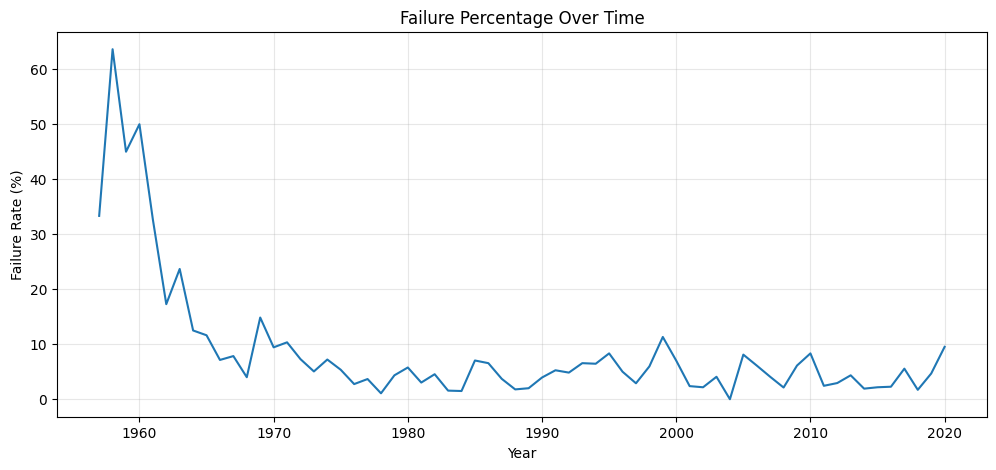

In [95]:
plt.figure(figsize=(12,5))
plt.plot(failure_rate['Year'], failure_rate['Failure_%'])
plt.title('Failure Percentage Over Time')
plt.xlabel('Year')
plt.ylabel('Failure Rate (%)')
plt.grid(alpha=0.3)
plt.show()

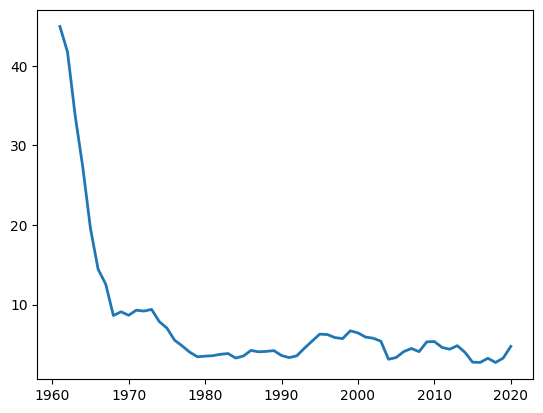

In [96]:
failure_rate['roll_5y'] = failure_rate['Failure_%'].rolling(5).mean()
plt.plot(failure_rate['Year'], failure_rate['roll_5y'], linewidth=2)

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [101]:
df_2020 = df[df['Year'] <= 2020].copy()

year_country_counts = (
    df_2020.groupby(['Year', 'Country'])
           .size()
           .reset_index(name='Launches')
)

yearly_country_leader = (
    year_country_counts
    .loc[year_country_counts.groupby('Year')['Launches'].idxmax()]
    .sort_values('Year')
)

yearly_country_leader.head(10), yearly_country_leader.tail(10)


(       Year                   Country  Launches
 0  1,957.00                Kazakhstan         2
 3  1,958.00  United States of America        17
 5  1,959.00  United States of America        16
 7  1,960.00  United States of America        30
 10 1,961.00  United States of America        43
 13 1,962.00  United States of America        59
 14 1,963.00                Kazakhstan        16
 17 1,964.00                Kazakhstan        26
 21 1,965.00                Kazakhstan        43
 27 1,966.00  United States of America        47,
         Year                   Country  Launches
 327 2,011.00  United States of America        18
 335 2,012.00  United States of America        13
 344 2,013.00  United States of America        19
 352 2,014.00  United States of America        23
 359 2,015.00  United States of America        19
 368 2,016.00  United States of America        25
 376 2,017.00  United States of America        29
 377 2,018.00                     China        39
 385 2,019

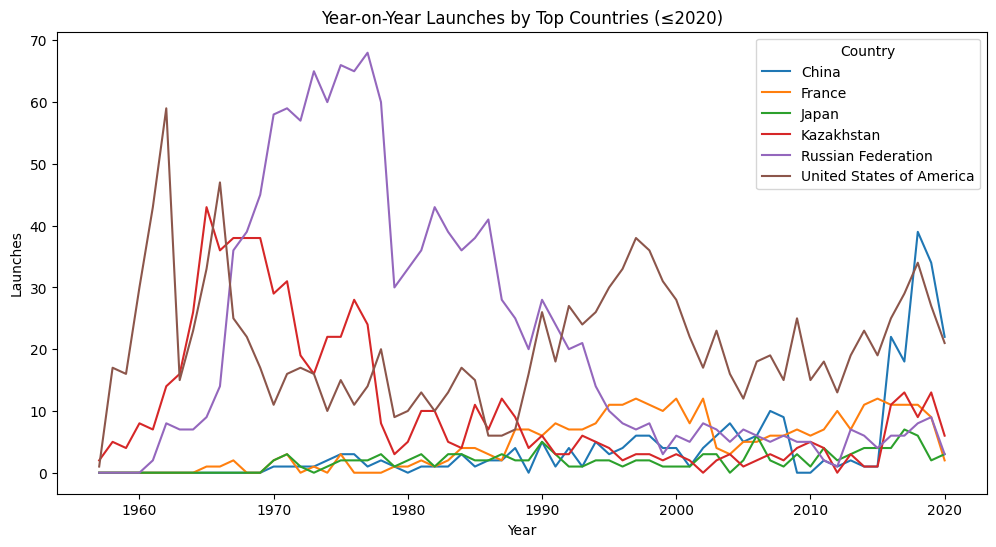

In [102]:
top_countries = df_2020['Country'].value_counts().head(6).index

pivot_countries = (
    df_2020[df_2020['Country'].isin(top_countries)]
    .groupby(['Year', 'Country'])
    .size()
    .unstack(fill_value=0)
)

pivot_countries.plot(figsize=(12,6), title='Year-on-Year Launches by Top Countries (≤2020)')
plt.xlabel('Year')
plt.ylabel('Launches')
plt.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [103]:
year_org_counts = (
    df_2020.groupby(['Year', 'Organisation'])
           .size()
           .reset_index(name='Launches')
)

yearly_org_leader = (
    year_org_counts
    .loc[year_org_counts.groupby('Year')['Launches'].idxmax()]
    .sort_values('Year')
)

yearly_org_leader.head(10), yearly_org_leader.tail(10)


(       Year  Organisation  Launches
 0  1,957.00     RVSN USSR         2
 2  1,958.00          AMBA         7
 10 1,959.00  US Air Force        10
 15 1,960.00  US Air Force        21
 19 1,961.00  US Air Force        23
 23 1,962.00  US Air Force        40
 26 1,963.00     RVSN USSR        23
 30 1,964.00     RVSN USSR        33
 36 1,965.00     RVSN USSR        52
 42 1,966.00     RVSN USSR        50,
         Year Organisation  Launches
 505 2,011.00          ULA        11
 516 2,012.00          ULA        10
 530 2,013.00          ULA        11
 541 2,014.00          ULA        14
 543 2,015.00  Arianespace        12
 554 2,016.00         CASC        22
 580 2,017.00       SpaceX        18
 585 2,018.00         CASC        37
 601 2,019.00         CASC        27
 618 2,020.00         CASC        19)

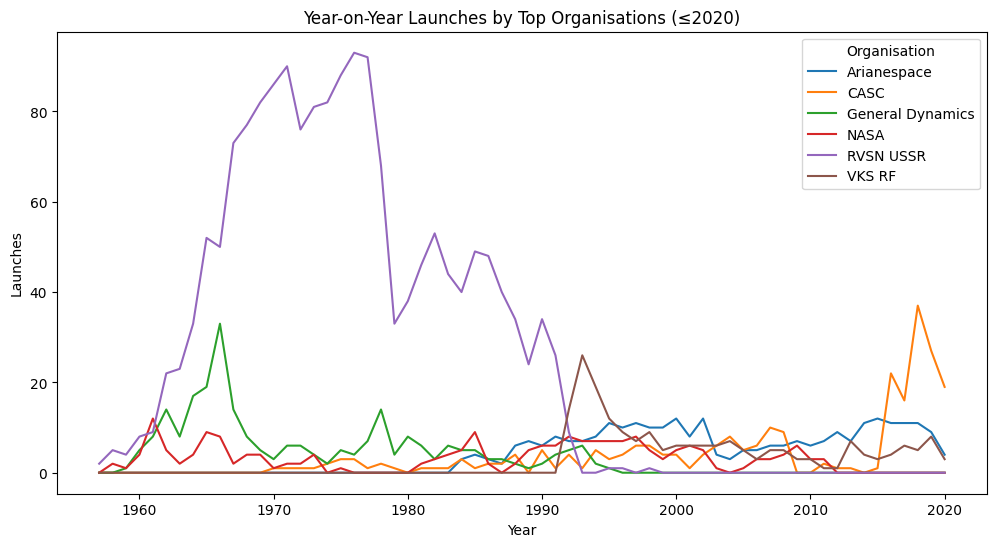

In [104]:
top_orgs = df_2020['Organisation'].value_counts().head(6).index

pivot_orgs = (
    df_2020[df_2020['Organisation'].isin(top_orgs)]
    .groupby(['Year', 'Organisation'])
    .size()
    .unstack(fill_value=0)
)

pivot_orgs.plot(figsize=(12,6), title='Year-on-Year Launches by Top Organisations (≤2020)')
plt.xlabel('Year')
plt.ylabel('Launches')
plt.show()